# Simple Regression Model with PyTorch


In this notebook, we walk through building a regression model using PyTorch as our deep learning framework. The goal is to learn the fundamentals of implementing a regression task in PyTorch.

The dataset is a small and relatively linear dataset from a [pistachio business](https://github.com/Fatemeh-Ghavidel/DataScienceProjects/blob/main/PistachioFamilyBusiness/PistachioBusiness.csv), with product weight as the feature and price as the target variable.

We will go through each step, providing explanations for every operation along the way.

## Imports

In [1]:
import torch
from torch import nn

from sklearn.preprocessing import MinMaxScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import requests
from io import StringIO

## Data

### Data Loading

In [2]:
# Load the Dataset from GitHub Repository
response = requests.get('https://raw.githubusercontent.com/Fatemeh-Ghavidel/DataScienceProjects/refs/heads/main/PistachioFamilyBusiness/PistachioBusiness.csv')
df = pd.read_csv(StringIO(response.text))


### Data Ingestion

In [3]:
# Get an Overview of the Dataset
print('DATASET: ')
print(df)
print('\nDATASET SUMMARY: ')
print(df.info())
print('\nNAN VALUES: ')
print(df.isnull().sum())

DATASET: 
    amount  price selling paying  type  year        date
0        2    480       T       K    W  1402           ?
1        2    500       T       K    W  1402           ?
2        2    500       I       K    W  1402           ?
3        1    250       I       K    W  1402           ?
4      0.5    120       T       c    W  1402           ?
..     ...    ...     ...     ...  ...   ...         ...
137      1    900       T       K    D  1404  10/24/2025
138      2   1800       T       K    D  1404  10/31/2025
139    0.6    500       T       C    D  1404  10/31/2025
140      2   1800       T       K    D  1404   11/2/2025
141    4.5   8000       I       K    D  1404   5/10/2026

[142 rows x 7 columns]

DATASET SUMMARY: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   amount   142 non-null    object
 1   price    142 non-null    int64 
 2   sellin

### Data Processing

The dataset contains `?` for missing values, which we convert to NaN for further investigation. In this case, there is only one missing value, which we remove using the `.dropna()` method.

The `amount` feature is stored as a string and needs to be converted to the float data type.

In [4]:
df['amount'] = df['amount'].replace('?', np.nan).astype(float)

In [5]:
df = df.dropna()

### Featrue and Target Processing


Since the product comes in two types, Wet (W) and Dry (D), and the pricing differs between these two groups, we filter the data to consider only the Wet product type.

In [6]:
x_train = df[df['type']=='W']['amount'].values
y_train = df[df['type']=='W']['price'].values
print('X_train: ', x_train)
print('\ny_train: ', y_train)

X_train:  [ 2.    2.    2.    1.    0.5   1.    2.    1.    2.    2.    1.    1.
  3.    2.5   2.    1.    0.75  2.    1.    1.    2.    2.    2.    1.
  3.    1.    2.    2.    1.    2.    1.    2.    5.    1.    3.    3.
  2.    5.    5.    1.    0.5   1.    1.    5.    1.   10.   20.    2.
  1.    5.5   2.    2.    1.    7.    5.    5.    3.    2.    3.    6.
  5.    1.    1.    2.    1.5   1.    2.    2.    3.    1.    2.    2.
  1.    5.    2.    2.    2.    4.    1.    2.    2.    4.    3.    5.
  2.    1.    1.    2.5   1.    5.    3.    3.    2.    3.    2.    2.
  1.    2.    2.    5.    4.    1.    3.    1.    1.  ]

y_train:  [ 480  500  500  250  120  240  240  300  470  480  240  240  720  600
  480  240  180  470  240  240  480  480  500  240  600  170  300  400
  200  300  200  400 1000  200  600  600  400 1000 1000  200  100  200
  200 1000  200 1800 3600  400  200 1100  400  400  200 1400 1000 1000
  540  400  600 1200 1000  200  200  400  300  200  400  400  600  200


We scale the data to bring both the feature and the target into the same range of values. We use `MinMaxScaler()`, which scales all values to a range between 0 and 1.

The training data (X_train and y_train) is in the form of NumPy arrays. To use them in PyTorch, we convert them to tensors.


In [7]:
## Scaling data
scaler_data = MinMaxScaler()
scaler_target = MinMaxScaler()
x_train = scaler_data.fit_transform(x_train.reshape(-1,1))
y_train = scaler_target.fit_transform(y_train.reshape(-1,1))


In [8]:
## Convert numpy array to Tensor
x_train = torch.from_numpy(x_train.astype(np.float32)).view(-1,1)
y_train = torch.from_numpy(y_train.astype(np.float32)).view(-1,1)


## Model

### Model Building

The `LinearRegressionModel` class defines a simple neural network for linear regression. It consists of two linear layers stacked together:
* Input layer: Takes a single input feature (weight) and maps it to 2 neurons.
* Output layer: Takes those 2 neurons and produces a single output (predicted price).

The `forward()` method defines how data flows through the network; it simply passes the input through both layers and returns the prediction.



In [9]:

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 2),
            nn.Linear(2, 1)
        )
    def forward(self, x):
        return self.network(x)


In [10]:
model = LinearRegressionModel()

### Loss Function and Optimizer

The loss function tells us how well the model is performing in its predictions. We use Mean Squared Error (MSE) loss, which calculates the average of the squared differences between the predicted and actual values.

The optimizer adjusts the gradients to minimize the loss. We use the Adam optimizer with a learning rate that controls how much the model's parameters are updated at each step.

In [12]:
learning_rate= 0.001
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)


### Model Traininig

* `torch.manual_seed(42)`; Fixes the random seed so the model initializes with the same weights every run, ensuring reproducible results.

* `num_epochs = 2000`; An epoch is one full pass through the training data. We train the model for 2000 epochs.

* `model.train()`; Sets the model to training mode.

* `y_pred = model(x_train)`; Forward pass: the model makes predictions based on current weights.

* `batch_loss = loss_fn(y_pred, y_train)`: Calculates how far the predictions are from the actual values.

* `optimizer.zero_grad()`; Clears old gradients before computing new ones (gradients accumulate by default).

* `batch_loss.backward()`; Backward pass: computes how much each parameter contributed to the error.

* `optimizer.step()`; Updates the model's weights to reduce the loss.

* The print statement displays the current epoch and loss value to monitor training progress.



In [13]:
torch.manual_seed(42)
num_epochs = 2000

for epoch in range(num_epochs):
    model.train()
    y_pred = model(x_train.requires_grad_())
    batch_loss = loss_fn(y_pred , y_train)

    optimizer.zero_grad()
    batch_loss.backward()
    optimizer.step()

    print('epoch {}, loss: {:.3f}'.format(epoch, batch_loss.item()))



epoch 0, loss: 0.066
epoch 1, loss: 0.065
epoch 2, loss: 0.064
epoch 3, loss: 0.063
epoch 4, loss: 0.063
epoch 5, loss: 0.062
epoch 6, loss: 0.061
epoch 7, loss: 0.060
epoch 8, loss: 0.059
epoch 9, loss: 0.058
epoch 10, loss: 0.057
epoch 11, loss: 0.057
epoch 12, loss: 0.056
epoch 13, loss: 0.055
epoch 14, loss: 0.054
epoch 15, loss: 0.053
epoch 16, loss: 0.053
epoch 17, loss: 0.052
epoch 18, loss: 0.051
epoch 19, loss: 0.051
epoch 20, loss: 0.050
epoch 21, loss: 0.049
epoch 22, loss: 0.049
epoch 23, loss: 0.048
epoch 24, loss: 0.047
epoch 25, loss: 0.047
epoch 26, loss: 0.046
epoch 27, loss: 0.045
epoch 28, loss: 0.045
epoch 29, loss: 0.044
epoch 30, loss: 0.044
epoch 31, loss: 0.043
epoch 32, loss: 0.043
epoch 33, loss: 0.042
epoch 34, loss: 0.042
epoch 35, loss: 0.041
epoch 36, loss: 0.040
epoch 37, loss: 0.040
epoch 38, loss: 0.040
epoch 39, loss: 0.039
epoch 40, loss: 0.039
epoch 41, loss: 0.038
epoch 42, loss: 0.038
epoch 43, loss: 0.037
epoch 44, loss: 0.037
epoch 45, loss: 0.03

### Model Evaluation

In [14]:
predicted = model(x_train)


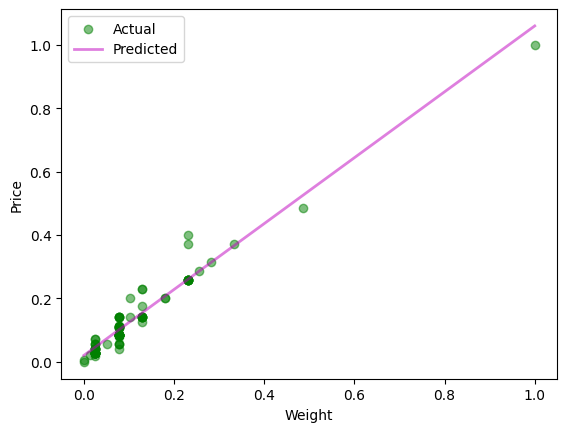

In [15]:
# Convert to numpy
x_np = x_train.detach().numpy()[:100]
y_np = y_train.detach().numpy()[:100]
pred_np = predicted.detach().numpy()[:100]

# Sort by x values
sorted_indices = np.argsort(x_np.flatten())
x_sorted = x_np.flatten()[sorted_indices]
pred_sorted = pred_np.flatten()[sorted_indices]

# Plot
plt.scatter(x_np, y_np, c='g',  alpha=0.5 , label='Actual')
plt.plot(x_sorted, pred_sorted, c="m", linewidth=2, alpha = 0.5, label='Predicted')
plt.xlabel("Weight")
plt.ylabel("Price")
plt.legend()
